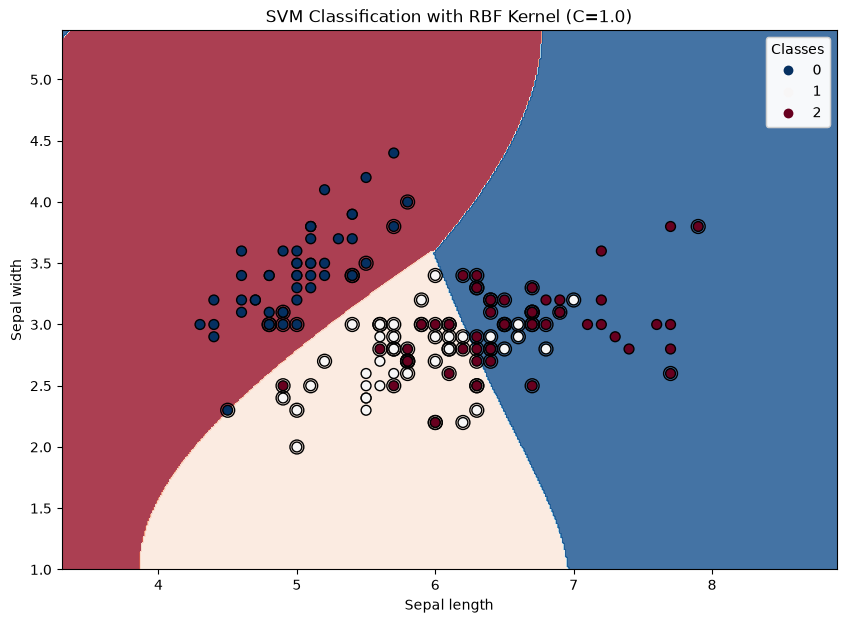

模型在训练集上的准确率: 0.83
预测样本 [[5.1, 3.5]] 的类别为: setosa


In [1]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets

# 1. 加载数据集
# 使用鸢尾花数据集，并仅取前两个特征（花萼长度和花萼宽度）以便于可视化
iris = datasets.load_iris()
X = iris.data[:, :2]  # 特征矩阵 (n_samples, n_features)
y = iris.target        # 目标标签 (n_samples,)

# 2. 创建并训练 SVM 模型
# 使用高斯核 (RBF)，C是正则化参数，gamma是核函数的系数
C = 1.0  # 惩罚参数，值越大，对误分类的惩罚越重
svc = svm.SVC(kernel='rbf', gamma='auto', C=C) # 使用SVC类
svc.fit(X, y) # 训练模型

# 3. 可视化结果
# 创建一个网格，用于绘制决策边界
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 500),
                        np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 500))

# 使用训练好的模型预测网格中每个点的类别
Z = svc.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 创建图形
plt.figure(figsize=(10, 7))

# 绘制决策边界和置信度区域
# contourf会根据Z的值填充不同区域的颜色
plt.contourf(xx, yy, Z, cmap=plt.cm.RdBu, alpha=0.8)

# 绘制支持向量机
# 支持向量是svc.support_vectors_属性
sv = svc.support_vectors_
plt.scatter(sv[:, 0], sv[:, 1], s=100, facecolors='none', edgecolors='k', label='Support Vectors')

# 绘制数据点
# 不同的花种用不同的颜色和标记表示
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu_r, edgecolor='k', s=50)
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.title('SVM Classification with RBF Kernel (C={})'.format(C))
plt.legend(loc='best')

# 添加图例说明
legend1 = plt.legend(*scatter.legend_elements(), title="Classes")
plt.gca().add_artist(legend1)

plt.show()

# 4. 模型评估与预测
# 在训练集上评估模型准确率
accuracy = svc.score(X, y)
print(f"模型在训练集上的准确率: {accuracy:.2f}")

# 使用模型进行新样本预测
# 例如，预测一个花萼长5.1cm，宽3.5cm的样本
new_sample = [[5.1, 3.5]]
predicted_class = svc.predict(new_sample)
print(f"预测样本 {new_sample} 的类别为: {iris.target_names[predicted_class][0]}")

模型在测试集上的准确率: 0.9778

分类报告:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



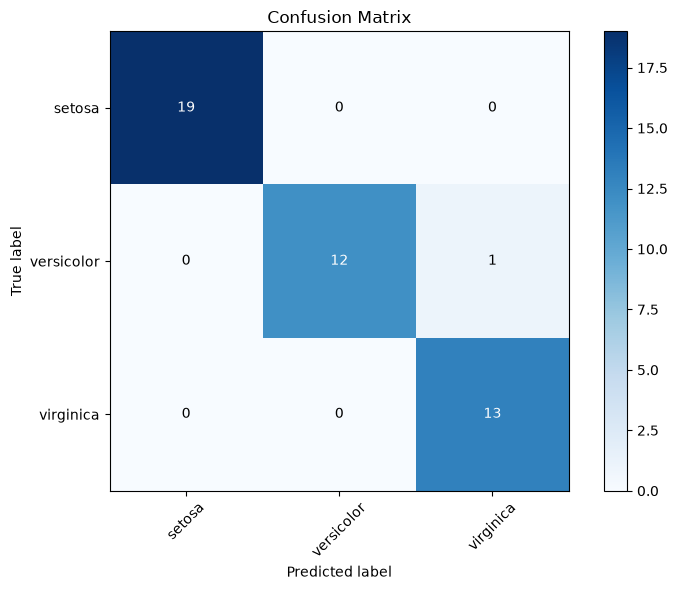

In [2]:
# 1. 导入必要的库
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

# 2. 加载数据集
iris = datasets.load_iris()
X = iris.data  # 特征矩阵 (150, 4)
y = iris.target # 目标向量 (150,)

# 3. 划分训练集和测试集 (70%训练, 30%测试)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 4. 创建并训练模型
# 鸢尾花的特征是连续值，因此使用高斯朴素贝叶斯
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# 5. 在测试集上进行预测
y_pred = gnb.predict(X_test)

# 6. 评估模型性能
accuracy = accuracy_score(y_test, y_pred)
print(f"模型在测试集上的准确率: {accuracy:.4f}")
print("\n分类报告:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# 7. 可视化混淆矩阵
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(iris.target_names))
plt.xticks(tick_marks, iris.target_names, rotation=45)
plt.yticks(tick_marks, iris.target_names)

# 在混淆矩阵中显示数值
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

# 1. 准备数据
texts = ["免费赢大奖", "最新课程优惠", "会议安排通知", "项目进展报告"]
labels = [1, 1, 0, 0]  # 1代表垃圾邮件，0代表正常邮件

# 2. 特征提取 (将文本转换为词频向量)
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(texts)

# 3. 训练模型
clf = MultinomialNB(alpha=1.0)  # alpha=1.0 表示使用拉普拉斯平滑
clf.fit(X, labels)

# 4. 预测新邮件
new_email = vectorizer.transform(["免费会议"])
prediction = clf.predict(new_email)
print("预测结果:", "垃圾邮件" if prediction[0] == 1 else "正常邮件")

预测结果: 正常邮件


In [4]:
# 1. 导入必要的库
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 2. 加载数据集
iris = load_iris()
X = iris.data  # 特征矩阵
y = iris.target  # 目标向量

# 3. 划分训练集和测试集 (70%训练, 30%测试)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 4. 创建并训练随机森林分类器
# n_estimators: 森林中树的数量
# random_state: 随机种子，确保结果可复现
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# 5. 在测试集上进行预测
y_pred = clf.predict(X_test)

# 6. 评估模型性能
accuracy = accuracy_score(y_test, y_pred)
print(f"模型在测试集上的准确率: {accuracy:.4f}")

# 7. (可选) 查看特征重要性
feature_importances = clf.feature_importances_
print("\n特征重要性:")
for feature, importance in zip(iris.feature_names, feature_importances):
    print(f"{feature}: {importance:.4f}")

模型在测试集上的准确率: 1.0000

特征重要性:
sepal length (cm): 0.1041
sepal width (cm): 0.0446
petal length (cm): 0.4173
petal width (cm): 0.4340


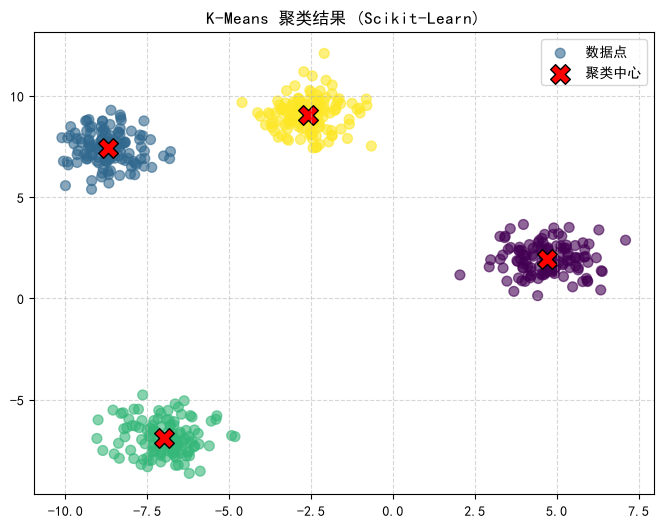

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# 解决中文字体显示问题
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows用黑体
plt.rcParams['axes.unicode_minus'] = False 

# 1. 生成模拟数据 (500个样本，4个真实簇)
X, y_true = make_blobs(n_samples=500, centers=4, cluster_std=0.8, random_state=42)

# 2. 构建并训练 K-Means 模型
# 注意：sklearn 1.4+ 版本推荐设置 n_init='auto' 以避免 FutureWarning
kmeans = KMeans(n_clusters=4, n_init='auto', random_state=42)
kmeans.fit(X)

# 3. 获取聚类标签和聚类中心
labels = kmeans.labels_
centers = kmeans.cluster_centers_

# 4. 可视化结果
plt.figure(figsize=(8, 6))
# 绘制数据点，按聚类标签上色
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50, alpha=0.6, label='数据点')
# 绘制聚类中心 (红色X标记)
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, edgecolor='black', label='聚类中心')

plt.title("K-Means 聚类结果 (Scikit-Learn)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

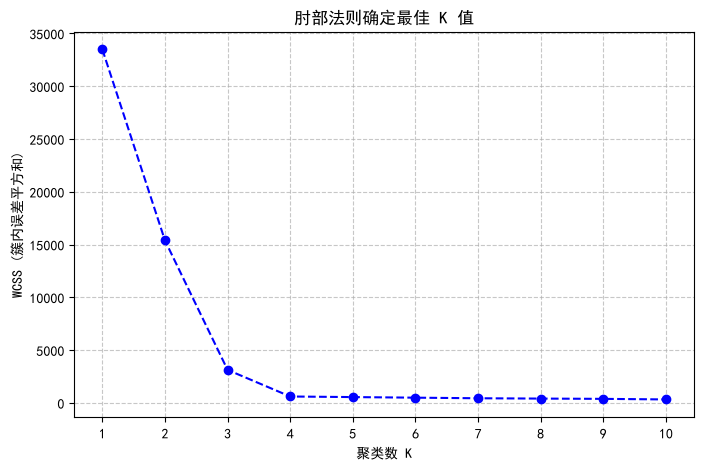

In [6]:
# 测试 K 从 1 到 10
k_values = range(1, 11)
wcss = [] # Within-Cluster Sum of Square (簇内误差平方和)

for k in k_values:
    km = KMeans(n_clusters=k, n_init='auto', random_state=42)
    km.fit(X)
    # km.inertia_ 即为 WCSS
    wcss.append(km.inertia_)

# 绘制肘部图
plt.figure(figsize=(8, 5))
plt.plot(k_values, wcss, marker='o', linestyle='--', color='b')
plt.title('肘部法则确定最佳 K 值')
plt.xlabel('聚类数 K')
plt.ylabel('WCSS (簇内误差平方和)')
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [7]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# 1. 定义弱学习器 (通常使用深度为1的决策树，即决策树桩)
base_estimator = DecisionTreeClassifier(max_depth=1, random_state=42)

# 2. 构建 AdaBoost 模型
# n_estimators: 弱学习器的最大迭代次数
# learning_rate: 学习率，控制每个弱学习器的权重贡献
ada_model = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

# 3. 训练与预测
ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_test)

print("=== AdaBoost 结果 ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ada):.4f}")

=== AdaBoost 结果 ===
Accuracy: 1.0000


In [8]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# ================= 1. 分类任务 =================
# 使用乳腺癌数据集
X_cls, y_cls = load_breast_cancer(return_X_y=True)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

# 构建随机森林分类器
# n_jobs=-1 表示使用所有可用的 CPU 核心并行训练，大幅提升速度
rf_clf = RandomForestClassifier(
    n_estimators=200,      # 树的数量
    max_depth=8,           # 限制树深，防止单棵树过拟合
    min_samples_split=5,   # 节点分裂所需的最小样本数
    random_state=42,
    n_jobs=-1              
)
rf_clf.fit(X_train_c, y_train_c)
y_pred_c = rf_clf.predict(X_test_c)
print(f"【分类任务】准确率: {accuracy_score(y_test_c, y_pred_c):.4f}")


# ================= 2. 回归任务 =================
# 使用加州房价数据集
X_reg, y_reg = fetch_california_housing(return_X_y=True)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# 构建随机森林回归器
rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_reg.fit(X_train_r, y_train_r)
y_pred_r = rf_reg.predict(X_test_r)
print(f"【回归任务】均方误差(MSE): {mean_squared_error(y_test_r, y_pred_r):.4f}")

【分类任务】准确率: 0.9474
【回归任务】均方误差(MSE): 0.2952


--- K=5 时的模型评估 ---
准确率 (Accuracy): 0.9111

分类报告 (Classification Report):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.79      1.00      0.88        15
   virginica       1.00      0.73      0.85        15

    accuracy                           0.91        45
   macro avg       0.93      0.91      0.91        45
weighted avg       0.93      0.91      0.91        45



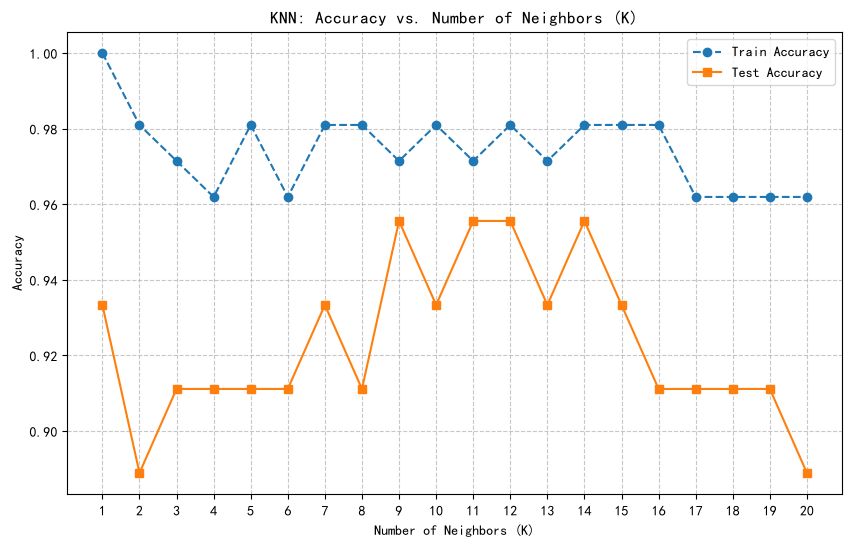

【调优结果】最佳的 K 值为: 9，对应的测试集准确率为: 0.9556


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# ==========================================
# 1. 加载数据集
# ==========================================
iris = load_iris()
X = iris.data    # 特征矩阵 (花萼长度、花萼宽度、花瓣长度、花瓣宽度)
y = iris.target  # 标签 (0: Setosa, 1: Versicolour, 2: Virginica)

# ==========================================
# 2. 划分训练集和测试集
# ==========================================
# test_size=0.3 表示 30% 用于测试，70% 用于训练
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# ==========================================
# 3. 数据标准化 (特征缩放)
# ==========================================
# 【专家提示】KNN 是基于距离度量的算法，如果特征量纲不一致，数值大的特征会主导距离计算。
# 因此，必须对数据进行标准化 (Z-score normalization)。
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # 在训练集上计算均值和方差，并进行转换
X_test_scaled = scaler.transform(X_test)       # 使用训练集的均值和方差转换测试集（防止数据泄露）

# ==========================================
# 4. 构建与训练 KNN 模型
# ==========================================
k = 5  # 初始设定邻居数为 5
# weights='uniform' 表示所有邻居权重相等；'distance' 表示距离越近权重越大
knn = KNeighborsClassifier(n_neighbors=k, weights='uniform', metric='minkowski', p=2) 
knn.fit(X_train_scaled, y_train)

# ==========================================
# 5. 模型预测与评估
# ==========================================
y_pred = knn.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"--- K={k} 时的模型评估 ---")
print(f"准确率 (Accuracy): {accuracy:.4f}\n")
print("分类报告 (Classification Report):")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# ==========================================
# 6. 进阶：超参数调优 (寻找最佳 K 值)
# ==========================================
k_values = range(1, 21)
train_accuracies = []
test_accuracies = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    
    # 记录训练集和测试集的准确率
    train_accuracies.append(knn_temp.score(X_train_scaled, y_train))
    test_accuracies.append(knn_temp.score(X_test_scaled, y_test))

# 可视化 K 值对模型性能的影响
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_accuracies, label='Train Accuracy', marker='o', linestyle='--')
plt.plot(k_values, test_accuracies, label='Test Accuracy', marker='s', linestyle='-')
plt.title('KNN: Accuracy vs. Number of Neighbors (K)')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 找出最佳 K 值
best_k = k_values[np.argmax(test_accuracies)]
print(f"【调优结果】最佳的 K 值为: {best_k}，对应的测试集准确率为: {max(test_accuracies):.4f}")